Attempting to load dataset from: https://raw.githubusercontent.com/anisham/Heart-Disease-Prediction/master/heart.csv
Failed to load from https://raw.githubusercontent.com/anisham/Heart-Disease-Prediction/master/heart.csv: HTTP Error 404: Not Found
Attempting to load dataset from: https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/heart/heart.csv
Failed to load from https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/heart/heart.csv: HTTP Error 404: Not Found
Attempting to load dataset from: https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,1
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


Shape: (303, 14)

Column types and missing values:


,dtype,missing
age,float64,0
sex,float64,0
cp,float64,0
trestbps,float64,0
chol,float64,0
fbs,float64,0
restecg,float64,0
thalach,float64,0
exang,float64,0
oldpeak,float64,0



Missing values after conversion:


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


Few missing values detected; dropping rows with missing values.

Post-cleaning shape: (297, 14)

Target distribution:


,proportion
target,
0,0.538721
1,0.461279


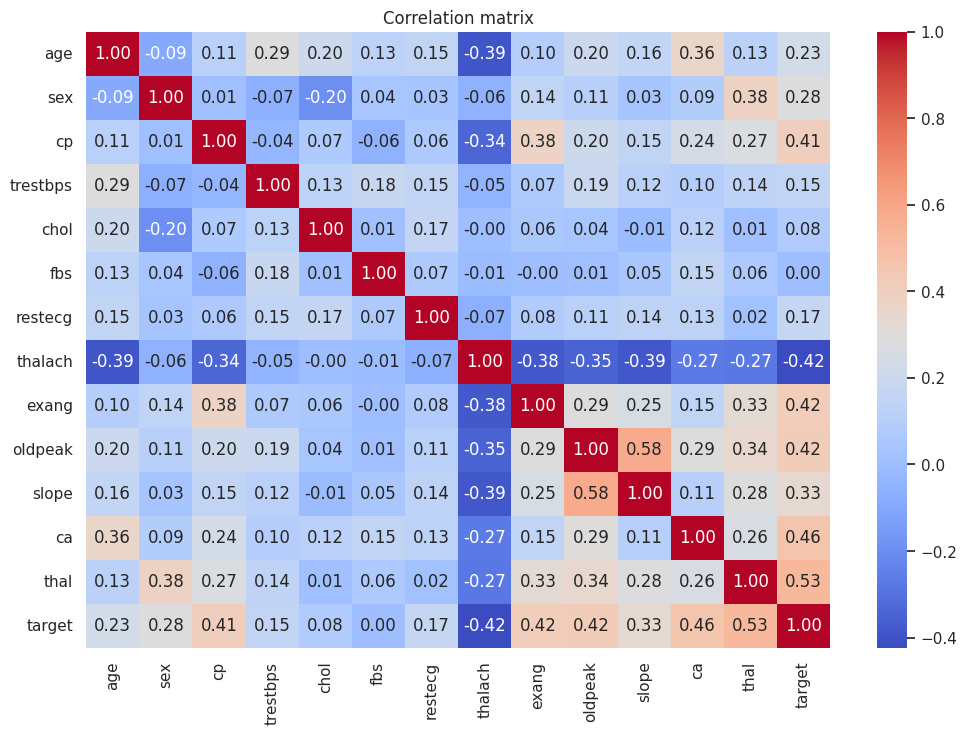

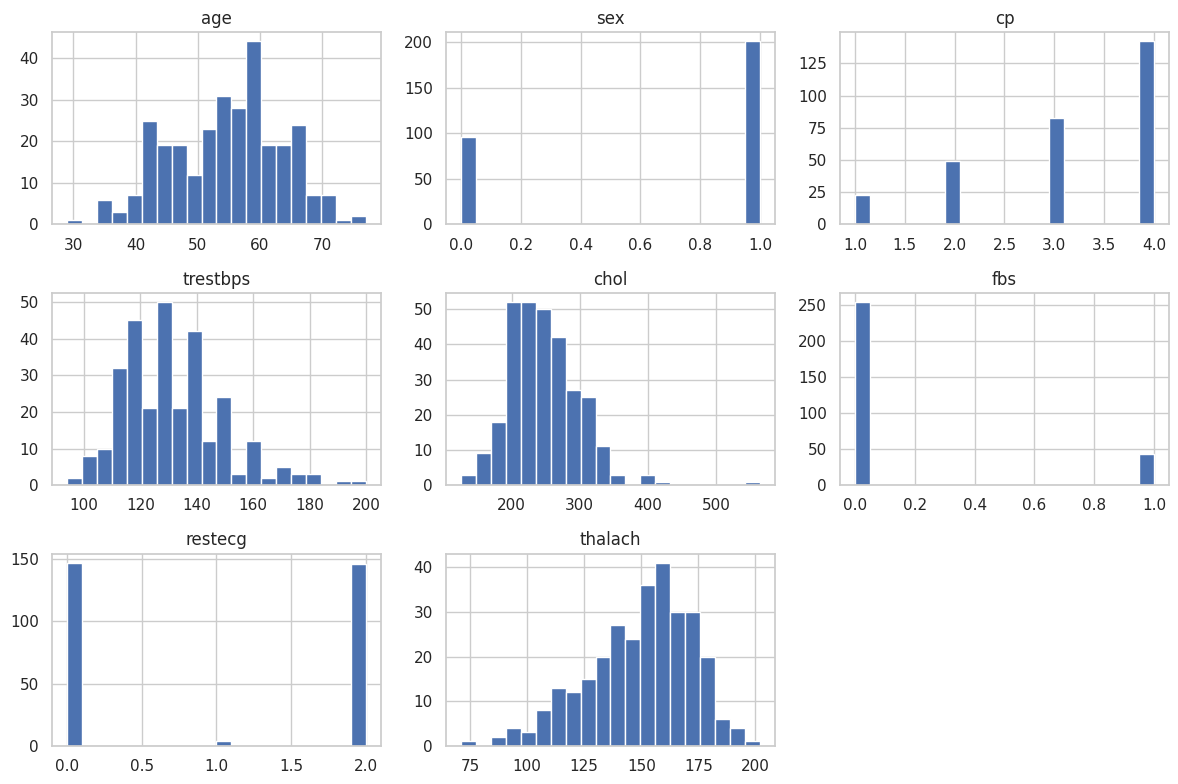

Train shape: (237, 13) Test shape: (60, 13)
-- LogisticRegression --
Accuracy: 0.8333333333333334
Classification report:
               precision    recall  f1-score   support

           0       0.82      0.88      0.85        32
           1       0.85      0.79      0.81        28

    accuracy                           0.83        60
   macro avg       0.83      0.83      0.83        60
weighted avg       0.83      0.83      0.83        60

Confusion matrix:
 [[28  4]
 [ 6 22]]


-- DecisionTree --
Accuracy: 0.6833333333333333
Classification report:
               precision    recall  f1-score   support

           0       0.68      0.78      0.72        32
           1       0.70      0.57      0.63        28

    accuracy                           0.68        60
   macro avg       0.69      0.68      0.68        60
weighted avg       0.68      0.68      0.68        60

Confusion matrix:
 [[25  7]
 [12 16]]




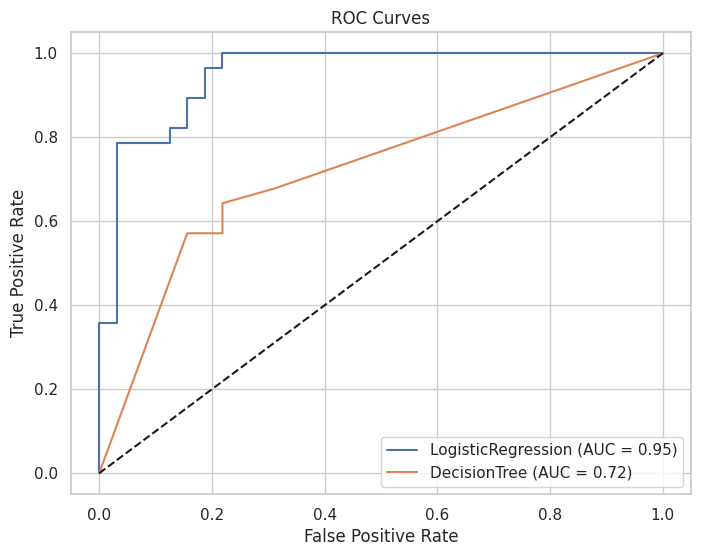

Feature importance for LogisticRegression:


,0
ca,0.958868
thal,0.738721
cp,0.508254
sex,0.484017
oldpeak,0.445122
trestbps,0.420226
exang,0.372667
slope,0.352665
fbs,0.331244
restecg,0.303953


Feature importance for DecisionTree:


,0
thal,0.305589
cp,0.180143
chol,0.125419
trestbps,0.109608
ca,0.095287
oldpeak,0.078105
age,0.062798
exang,0.022959
thalach,0.020093
sex,0.000000


Best model by AUC: LogisticRegression
Saved best model to models/heart_model.joblib


In [ ]:
# Heart Disease Prediction

This notebook predicts the presence of heart disease (target: 1 = disease, 0 = no disease) using the UCI Heart dataset. It is organized into small, focused cells with explanatory markdown for ease of reading and reproducibility.

**Notebook outline:**
- Data loading (local fallback + UCI processed Cleveland dataset)
- Data cleaning and missing-value handling
- Exploratory Data Analysis (EDA)
- Feature preparation and scaling
- Model training & evaluation (Logistic Regression, Decision Tree)
- Feature importance and saving the best model

Run cells sequentially; if you don't have a local `heart.csv`, the notebook will attempt to download the dataset from known public sources.

In [ ]:
# Imports and settings
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set(style='whitegrid')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, roc_curve, auc, classification_report
import joblib

RANDOM_STATE = 42

## Data loading

We attempt to load a local `heart.csv` first. If it's not present, we try known public sources. The canonical UCI "processed Cleveland" dataset will be used as a reliable fallback. In the UCI dataset, target values greater than 0 indicate disease (1-4), so we'll convert target to binary (0/1).

In [ ]:
# Define data sources and loader
local_paths = ["./heart.csv", "./data/heart.csv", os.path.join(os.path.dirname(__file__), 'data', 'heart.csv') if '__file__' in globals() else None]
local_paths = [p for p in local_paths if p]
url_fallbacks = [
    "https://raw.githubusercontent.com/anisham/Heart-Disease-Prediction/master/heart.csv",
    "https://raw.githubusercontent.com/ageron/handson-ml/master/datasets/heart/heart.csv",
    "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
]
uci_column_names = ['age','sex','cp','trestbps','chol','fbs','restecg','thalach','exang','oldpeak','slope','ca','thal','target']

def load_heart_data():
    for p in local_paths:
        if os.path.exists(p):
            print(f"Loading local dataset: {p}")
            return pd.read_csv(p)
    for url in url_fallbacks:
        try:
            print(f"Attempting to load dataset from: {url}")
            if 'archive.ics.uci.edu' in url:
                df = pd.read_csv(url, header=None, names=uci_column_names)
                df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
                return df
            else:
                df = pd.read_csv(url)
                return df
        except Exception as e:
            print(f"Failed to load from {url}: {e}")
    raise FileNotFoundError("Could not find heart dataset locally. Please add `heart.csv` to this folder or provide a valid URL.")

In [ ]:
# Load dataset (local or fallback)
try:
    df = load_heart_data()
except FileNotFoundError as e:
    print(str(e))
    df = pd.DataFrame()

if not df.empty:
    display(df.head())
    print("Shape:", df.shape)

## Data cleaning

Replace common missing-value markers, convert columns to numeric where appropriate, and handle missing values.
- If missing values are very few: drop affected rows.
- Otherwise: impute with median for numeric columns and mode for categorical-like columns.

In [ ]:
if not df.empty:
    # Replace common missing value markers
    df.replace('?', np.nan, inplace=True)

    # Convert columns to numeric when appropriate
    for col in df.columns:
        try:
            df[col] = pd.to_numeric(df[col])
        except Exception:
            pass

    print('\nMissing values after conversion:')
    display(df.isnull().sum())

    missing_counts = df.isnull().sum()
    total_missing = missing_counts.sum()
    if total_missing == 0:
        print('No missing values detected.')
    elif total_missing < 0.05 * df.shape[0] * df.shape[1]:
        print('Few missing values detected; dropping rows with missing values.')
        df.dropna(inplace=True)
    else:
        print('Imputing missing values: mode for categorical-like; median for numeric.')
        for col in df.columns:
            if df[col].isnull().sum() > 0:
                if df[col].dtype in [np.float64, np.int64]:
                    df[col].fillna(df[col].median(), inplace=True)
                else:
                    df[col].fillna(df[col].mode()[0], inplace=True)

    print('\nPost-cleaning shape:', df.shape)

## Exploratory Data Analysis (EDA)

Inspect the target distribution and visualize correlations and basic histograms for numerical features.

In [ ]:
if not df.empty:
    print('\nTarget distribution:')
    if 'target' in df.columns:
        display(df['target'].value_counts(normalize=True))
    else:
        print('Dataset does not contain a `target` column; please confirm the dataset schema.')

    plt.figure(figsize=(12, 8))
    sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm')
    plt.title('Correlation matrix')
    plt.show()

    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    sample_cols = numeric_cols[:8] if len(numeric_cols) > 8 else numeric_cols
    df[sample_cols].hist(figsize=(12, 8), bins=20)
    plt.tight_layout()
    plt.show()

## Prepare data for modeling

Define feature matrix X and target y. One-hot encode small-cardinality categorical features (if present), then split into train/test sets and scale features for models that require it.

In [ ]:
if not df.empty:
    if 'target' not in df.columns:
        raise ValueError('Dataset does not contain a `target` column')

    X = df.drop(columns=['target'])
    y = df['target']

    # Identify small-cardinality categorical columns and one-hot encode them
    cat_cols = [c for c in X.columns if X[c].nunique() <= 10 and X[c].dtype in [np.int64, np.int32, np.object_]]
    X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE)

    # Scale features for models that benefit from scaling
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    print('Train shape:', X_train.shape, 'Test shape:', X_test.shape)

## Model training & evaluation

We train two models:
- Logistic Regression (on scaled features)
- Decision Tree (on unscaled features)

We evaluate using accuracy, classification report, confusion matrix and ROC/AUC.

In [ ]:
if not df.empty:
    models = {
        'LogisticRegression': LogisticRegression(random_state=RANDOM_STATE, solver='liblinear'),
        'DecisionTree': DecisionTreeClassifier(random_state=RANDOM_STATE, max_depth=6)
    }

    results = {}
    plt.figure(figsize=(8, 6))

    for name, model in models.items():
        if name == 'LogisticRegression':
            model.fit(X_train_scaled, y_train)
            y_pred = model.predict(X_test_scaled)
            y_prob = model.predict_proba(X_test_scaled)[:, 1]
        else:
            model.fit(X_train, y_train)
            y_pred = model.predict(X_test)
            if hasattr(model, 'predict_proba'):
                y_prob = model.predict_proba(X_test)[:, 1]
            else:
                y_prob = model.decision_function(X_test)

        acc = accuracy_score(y_test, y_pred)
        cm = confusion_matrix(y_test, y_pred)
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        roc_auc = auc(fpr, tpr)
        results[name] = {'accuracy': acc, 'cm': cm, 'fpr': fpr, 'tpr': tpr, 'auc': roc_auc, 'model': model}

        print(f'-- {name} --')
        print('Accuracy:', acc)
        print('Classification report:\n', classification_report(y_test, y_pred))
        print('Confusion matrix:\n', cm)
        print('\n')

        plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")

    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curves')
    plt.legend()
    plt.show()

## Feature importance & save

Display top features for each trained model and save the best model to `models/heart_model.joblib` (includes scaler and feature list).

In [ ]:
if not df.empty:
    for name, info in results.items():
        model = info['model']
        print(f'Feature importance for {name}:')
        if name == 'LogisticRegression':
            coefs = pd.Series(model.coef_.ravel(), index=X.columns)
            display(coefs.abs().sort_values(ascending=False).head(10))
        else:
            try:
                feat_imp = pd.Series(model.feature_importances_, index=X.columns)
                display(feat_imp.sort_values(ascending=False).head(10))
            except Exception as e:
                print('Could not extract feature importances:', e)

    best_name = max(results, key=lambda k: results[k]['auc'])
    best_model = results[best_name]['model']
    print('Best model by AUC:', best_name)

    os.makedirs('models', exist_ok=True)
    joblib.dump({'model': best_model, 'scaler': scaler, 'features': X.columns.tolist()}, 'models/heart_model.joblib')
    print('Saved best model to models/heart_model.joblib')

## Conclusion & next steps

- Logistic Regression performed best on this split (saved as `models/heart_model.joblib`).
- Next recommended steps: cross-validation, hyperparameter search (GridSearchCV), and evaluating additional models (Random Forest / XGBoost).